# Install dependencies and environment setup

In [1]:
%pip -qqq install miditoolkit pandarallel kagglehub music21 scikit-learn torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.9 MB/s eta 0:00:00


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [3]:
from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


# Import Dataset from Kaggle

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

directory = kagglehub.dataset_download(
  "blanderbuss/midi-classic-music"
)

100%|██████████| 68.2M/68.2M [00:00<00:00, 196MB/s]

Extracting files...


# Restructure and filter midi_files

Filter for Bach, Beethoven, Chopin, and Mozart midi files only

In [5]:
import pandas as pd
import glob

def read_midi_files(composers):
  midi_files = []
  for composer in composers:
    midi_filenames = glob.glob(f'{directory}/midiclassics/{composer}/*.mid')
    midi_filenames += glob.glob(f'{directory}/midiclassics/{composer}/**/*.mid')
    print(f'Found {len(midi_filenames)} .mid files for {composer}')
    midi_files += [{
        'composer': composer,
        'filename': filename
    } for filename in midi_filenames]

  df = pd.DataFrame(midi_files)
  return df

df = read_midi_files(['Bach', 'Beethoven', 'Chopin', 'Mozart'])
df

Found 876 .mid files for Bach
Found 212 .mid files for Beethoven
Found 136 .mid files for Chopin
Found 219 .mid files for Mozart


,composer,filename
0,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...
1,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...
2,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...
3,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...
4,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...
...,...,...
1438,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...
1439,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...
1440,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...
1441,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...


# Data pre-processing and feature extraction

The `Composer_Dataset` directory contains 3 subdirectories: `dev`, `test`, and `train`. Each subdirectory contains additional subdirectories for each composer, which contain .mid (MIDI) files. The files must be pre-processed to extract relevant features for our deep learning model. The following features may be extracted from the MIDI files:

- Key signature
- Time signature
- Tempo
- Sequence of notes (pitch, duration, velocity)
- Instrumentation
- etc.

In [6]:
from miditoolkit import MidiFile

def read_midi(filename):
    try:
        midi_obj = MidiFile(filename)
        extracted_data = {
            'ticks_per_beat': midi_obj.ticks_per_beat,
            'max_tick': midi_obj.max_tick,
            'tempo_changes_count': len(midi_obj.tempo_changes),
            'time_signature_changes_count': len(midi_obj.time_signature_changes),
            'key_signature_changes_count': len(midi_obj.key_signature_changes),
            'num_instruments': midi_obj.num_instruments,
            'instrument_names': [inst.name for inst in midi_obj.instruments],
            'instruments_data': {
                inst.name: {
                    'is_drum': inst.is_drum,
                    'program': inst.program,
                    'notes': [{
                        'pitch': note.pitch,
                        'start': note.start,
                        'end': note.end,
                        'duration': note.duration,
                        'velocity': note.velocity
                    } for note in inst.notes]
                } for inst in midi_obj.instruments
            }
        }
        return extracted_data
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None

df['midi_data'] = df['filename'].parallel_apply(read_midi)

Error reading /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1/midiclassics/Beethoven/Anhang 14-3.mid: Could not decode key with 3 flats and mode 255


In [7]:
# Remove midi files that cannot be parsed
before_len = len(df)
df = df.dropna()
after_len = len(df)
print(f'Removed {before_len - after_len} midi file(s) that cannot be parsed')

Removed 1 midi file(s) that cannot be parsed


### DATA PRE-PROCESSING, MIDI CONVERSION, AUGMENTATION, AND EVENT FEATURE EXTRACTION
Symbolic-music models commonly represent a score as an ordered sequence of note
events. MusicBERT's OctupleMIDI representation demonstrates the usefulness of
metrical position, instrument, pitch, duration, velocity, tempo, and time
signature for symbolic-music understanding (Zeng et al., 2021). Accordingly,
this cell extracts a compact event representation containing pitch, pitch
class, duration, velocity, onset spacing, instrument program, tempo, and meter.

Pitch transposition and tempo scaling are used as label-preserving training
augmentations. They increase tonal and temporal variation while retaining the
composer label. Augmentation must be applied only after creating grouped
train/validation/test splits; all versions sharing the same ``source_id`` must
remain in the same split to prevent data leakage.

### APA 7 references
Cuthbert, M. S., & Ariza, C. (2010). music21: A toolkit for
    computer-aided musicology and symbolic music data. In J. S. Downie &
    R. C. Veltkamp (Eds.), Proceedings of the 11th International Society
    for Music Information Retrieval Conference (pp. 637–642).

McLeod, A., Owers, J., & Yoshii, K. (2020). The MIDI degradation toolkit:
    Symbolic music augmentation and correction. arXiv.
    https://doi.org/10.48550/arXiv.2010.00059

Zeng, M., Tan, X., Wang, R., Ju, Z., Qin, T., & Liu, T.-Y. (2021).
    MusicBERT: Symbolic music understanding with large-scale pre-training.
    In Findings of the Association for Computational Linguistics:
    ACL-IJCNLP 2021 (pp. 791–800).
    https://doi.org/10.18653/v1/2021.findings-acl.70

In [8]:
from __future__ import annotations

from bisect import bisect_right
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
from miditoolkit import MidiFile

# music21 is used only when a source score is not already MIDI.
from music21 import converter


PREPROCESSED_DIR = Path("preprocessed_midi")
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Conservative transformations help preserve recognizable compositional style.
MAX_EVENTS = 2048

AUGMENTATION_PLAN = [
    ("pitch_-2", -2, 1.00),
    ("pitch_+2",  2, 1.00),
    ("tempo_0.95", 0, 0.95),
    ("tempo_1.05", 0, 1.05),
    ("pitch_-1", -1, 1.00),
    ("pitch_+1",  1, 1.00),
]

TARGET_ROWS_PER_CLASS = 613


def stable_source_id(path: str | Path) -> str:
    """Return a stable ID used to group original and augmented versions."""
    return hashlib.sha1(str(Path(path).resolve()).encode("utf-8")).hexdigest()[:16]


def convert_score_to_midi(score_path: str | Path,
                          output_dir: Path = PREPROCESSED_DIR) -> Path:
    """
    Convert MusicXML, MXL, ABC, or another music21-readable score to MIDI.
    Existing MIDI files are returned unchanged.
    """
    score_path = Path(score_path)
    if score_path.suffix.lower() in {".mid", ".midi"}:
        return score_path

    output_path = output_dir / f"{score_path.stem}.mid"
    parsed_score = converter.parse(str(score_path))
    parsed_score.write("midi", fp=str(output_path))
    return output_path


def augment_midi(midi_path: str | Path,
                 pitch_shift: int = 0,
                 tempo_factor: float = 1.0,
                 output_dir: Path = PREPROCESSED_DIR) -> Path:
    """
    Create an augmented MIDI file.

    Pitch shift changes non-drum note pitches. Tempo scaling modifies tempo
    events without changing the notated tick positions. Invalid MIDI pitches
    outside 0–127 are clipped.
    """
    midi_path = Path(midi_path)
    midi = MidiFile(str(midi_path))

    for instrument in midi.instruments:
        if not instrument.is_drum and pitch_shift != 0:
            for note in instrument.notes:
                note.pitch = int(np.clip(note.pitch + pitch_shift, 0, 127))

    if tempo_factor != 1.0:
        for change in midi.tempo_changes:
            change.tempo = float(np.clip(change.tempo * tempo_factor, 20.0, 300.0))

    suffix = f"_ps{pitch_shift:+d}_tf{tempo_factor:.2f}".replace(".", "p")
    output_path = output_dir / f"{midi_path.stem}{suffix}.mid"
    midi.dump(str(output_path))
    return output_path


def _active_tempo(tick: int, tempo_ticks: list[int], tempo_values: list[float]) -> float:
    """Return the most recent tempo at a note onset."""
    idx = max(0, bisect_right(tempo_ticks, tick) - 1)
    return tempo_values[idx]


def _active_meter(tick: int,
                  meter_ticks: list[int],
                  numerators: list[int],
                  denominators: list[int]) -> tuple[int, int]:
    """Return the most recent time signature at a note onset."""
    idx = max(0, bisect_right(meter_ticks, tick) - 1)
    return numerators[idx], denominators[idx]


def extract_event_features(midi_path: str | Path,
                           max_events: int = MAX_EVENTS) -> dict:
    """
    Convert a MIDI file into a chronological sequence of event-level features.

    Each event contains:
      pitch, pitch_class, duration_beats, velocity, onset_delta_beats,
      program, tempo_bpm, time_signature_numerator, and
      time_signature_denominator.
    """
    midi = MidiFile(str(midi_path))
    tpq = max(int(midi.ticks_per_beat), 1)

    tempo_changes = sorted(midi.tempo_changes, key=lambda x: x.time)
    tempo_ticks = [int(x.time) for x in tempo_changes] or [0]
    tempo_values = [float(x.tempo) for x in tempo_changes] or [120.0]

    meter_changes = sorted(midi.time_signature_changes, key=lambda x: x.time)
    meter_ticks = [int(x.time) for x in meter_changes] or [0]
    numerators = [int(x.numerator) for x in meter_changes] or [4]
    denominators = [int(x.denominator) for x in meter_changes] or [4]

    raw_events = []
    for instrument in midi.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            raw_events.append((
                int(note.start), int(note.end), int(note.pitch),
                int(note.velocity), int(instrument.program)
            ))

    raw_events.sort(key=lambda e: (e[0], e[2], e[1]))
    raw_events = raw_events[:max_events]

    features = []
    previous_start = raw_events[0][0] if raw_events else 0
    for start, end, pitch, velocity, program in raw_events:
        numerator, denominator = _active_meter(
            start, meter_ticks, numerators, denominators
        )
        features.append({
            "pitch": pitch,
            "pitch_class": pitch % 12,
            "duration_beats": max(end - start, 1) / tpq,
            "velocity": velocity / 127.0,
            "onset_delta_beats": max(start - previous_start, 0) / tpq,
            "program": program,
            "tempo_bpm": _active_tempo(start, tempo_ticks, tempo_values),
            "time_signature_numerator": numerator,
            "time_signature_denominator": denominator,
        })
        previous_start = start

    return {
        "event_features": features,
        "sequence_length": len(features),
        "ticks_per_beat": tpq,
    }


def build_preprocessed_dataset(
    source_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Convert source files to MIDI and extract original event sequences.

    Augmentation is deliberately excluded here. It is applied later only to
    the training split to prevent leakage into validation and test data.
    """
    records = []

    for row in source_df[["composer", "filename"]].itertuples(index=False):
        try:
            midi_path = convert_score_to_midi(row.filename)
            source_id = stable_source_id(row.filename)

            extracted = extract_event_features(midi_path)

            records.append({
                "composer": row.composer,
                "source_id": source_id,
                "augmentation": "original",
                "pitch_shift": 0,
                "tempo_factor": 1.0,
                "midi_path": str(midi_path),
                **extracted,
            })

        except Exception as exc:
            print(f"Skipped {row.filename}: {exc}")

    return pd.DataFrame(records)

In [9]:
# Preprocess original MIDI files only.
# Source-level splitting and training-only augmentation are performed later to
# prevent augmented versions of the same piece appearing in multiple splits.
processed_df = build_preprocessed_dataset(df)

print(f"Created {len(processed_df):,} original sequences.")
display(
    processed_df[
        ["composer", "source_id", "augmentation", "sequence_length", "midi_path"]
    ].head()
)
print("\nClass counts:")
display(processed_df["composer"].value_counts())

Created 1,442 original sequences.


,composer,source_id,augmentation,sequence_length,midi_path
0,Bach,2a18ea47ae49291c,original,814,/root/.cache/kagglehub/datasets/blanderbuss/mi...
1,Bach,a2378863142d1607,original,416,/root/.cache/kagglehub/datasets/blanderbuss/mi...
2,Bach,8323645f0f2971a4,original,2048,/root/.cache/kagglehub/datasets/blanderbuss/mi...
3,Bach,68015facf1567230,original,902,/root/.cache/kagglehub/datasets/blanderbuss/mi...
4,Bach,63ba2b260bb9866b,original,2048,/root/.cache/kagglehub/datasets/blanderbuss/mi...



Class counts:


,count
composer,
Bach,876
Mozart,219
Beethoven,211
Chopin,136


### Dataset formatting, leakage-safe splitting, and NumPy serialization

This section converts the event dictionaries in `processed_df` into fixed-size numerical tensors for CNN/LSTM models. Splits are performed at the **original source-file level** using `source_id`, with stratification by composer. All augmented variants of a source are restricted to the training set, while validation and test sets contain only original MIDI sequences. This prevents near-duplicate augmented examples from leaking across partitions and producing overly optimistic evaluation results.

Generated artifacts:

- `X_train`, `X_val`, `X_test`: event tensors with shape `(samples, MAX_EVENTS, features)`
- `mask_train`, `mask_val`, `mask_test`: valid-event masks
- `y_train`, `y_val`, `y_test`: integer composer labels
- compressed `.npz` split files, a label map, a feature specification, and CSV manifests

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Reproducible split configuration.
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

# Fixed feature order used by every split and by downstream models.
FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "duration_beats",
    "velocity",
    "onset_delta_beats",
    "program",
    "tempo_bpm",
    "time_signature_numerator",
    "time_signature_denominator",
]

SERIALIZED_DIR = Path("serialized_dataset")
SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)


def validate_processed_dataframe(dataframe: pd.DataFrame) -> None:
    """Check that preprocessing created the columns required below."""
    required = {"composer", "source_id", "augmentation", "event_features"}
    missing = required.difference(dataframe.columns)
    if missing:
        raise ValueError(
            "processed_df is missing required columns: " + ", ".join(sorted(missing))
        )
    if dataframe.empty:
        raise ValueError("processed_df is empty; run the preprocessing cell first.")


def make_source_level_splits(dataframe: pd.DataFrame):
    """
    Split unique original sources with composer stratification.

    Augmented rows are deliberately excluded when deriving source-level labels.
    """
    source_table = (
        dataframe[["source_id", "composer"]]
        .drop_duplicates()
        .sort_values(["composer", "source_id"])
        .reset_index(drop=True)
    )

    # Every source must map to exactly one composer.
    conflicts = source_table.groupby("source_id")["composer"].nunique()
    if (conflicts > 1).any():
        bad_ids = conflicts[conflicts > 1].index.tolist()[:5]
        raise ValueError(f"Some source IDs have multiple composer labels: {bad_ids}")

    class_counts = source_table["composer"].value_counts()
    if (class_counts < 3).any():
        raise ValueError(
            "Each composer needs at least three original files for train/validation/test "
            f"splitting. Counts: {class_counts.to_dict()}"
        )

    train_sources, temp_sources = train_test_split(
        source_table,
        train_size=TRAIN_SIZE,
        random_state=RANDOM_STATE,
        stratify=source_table["composer"],
    )

    # 15% validation and 15% test means splitting the remaining 30% equally.
    relative_test_size = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)
    val_sources, test_sources = train_test_split(
        temp_sources,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
        stratify=temp_sources["composer"],
    )

    return train_sources, val_sources, test_sources


def select_rows_for_split(
    dataframe: pd.DataFrame,
    source_table: pd.DataFrame,
    include_augmentations: bool,
) -> pd.DataFrame:
    """Select rows by source ID and optionally retain augmented variants."""
    selected = dataframe[dataframe["source_id"].isin(source_table["source_id"])].copy()
    if not include_augmentations:
        selected = selected[selected["augmentation"] == "original"].copy()

    return selected.sort_values(
        ["composer", "source_id", "augmentation"]
    ).reset_index(drop=True)


def events_to_tensor(
    event_sequences,
    max_events: int = MAX_EVENTS,
    feature_names=FEATURE_NAMES,
):
    """
    Convert variable-length event dictionaries to a padded float32 tensor.

    Padding rows contain zeros. The mask distinguishes padding from real events.
    Selected continuous features are scaled to numerically stable ranges using
    fixed MIDI/music-domain constants rather than statistics from validation/test.
    """
    n_samples = len(event_sequences)
    n_features = len(feature_names)
    X = np.zeros((n_samples, max_events, n_features), dtype=np.float32)
    mask = np.zeros((n_samples, max_events), dtype=np.bool_)

    # Fixed, interpretable scaling. pitch_class is already bounded by 0–11.
    scale = {
        "pitch": 127.0,
        "pitch_class": 11.0,
        "duration_beats": 16.0,
        "velocity": 1.0,  # already normalized during feature extraction
        "onset_delta_beats": 16.0,
        "program": 127.0,
        "tempo_bpm": 300.0,
        "time_signature_numerator": 16.0,
        "time_signature_denominator": 16.0,
    }

    for sample_index, events in enumerate(event_sequences):
        if not isinstance(events, list):
            continue
        usable_events = events[:max_events]
        for event_index, event in enumerate(usable_events):
            X[sample_index, event_index] = [
                np.clip(float(event.get(name, 0.0)) / scale[name], 0.0, 1.0)
                for name in feature_names
            ]
        mask[sample_index, :len(usable_events)] = True

    return X, mask


def encode_and_format(split_df: pd.DataFrame, label_to_index: dict):
    """Create X, mask, and integer y arrays for one dataframe split."""
    X, mask = events_to_tensor(split_df["event_features"].tolist())
    encoded = split_df["composer"].map(label_to_index)

    if encoded.isna().any():
        unknown = split_df.loc[encoded.isna(), "composer"].unique().tolist()
        raise ValueError(f"Unknown composer labels: {unknown}")

    y = encoded.to_numpy(dtype=np.int64)

    return X, mask, y


def save_split(name, X, mask, y, manifest: pd.DataFrame):
    """Serialize arrays as compressed NPZ and metadata as CSV."""
    np.savez_compressed(
        SERIALIZED_DIR / f"{name}.npz",
        X=X,
        mask=mask,
        y=y,
        feature_names=np.asarray(FEATURE_NAMES),
    )
    manifest_columns = [
        column for column in
        ["composer", "source_id", "augmentation", "midi_path", "sequence_length"]
        if column in manifest.columns
    ]
    manifest[manifest_columns].to_csv(
        SERIALIZED_DIR / f"{name}_manifest.csv", index=False
    )

In [11]:
def balance_training_split(
    training_df: pd.DataFrame,
    target_rows_per_class: int = TARGET_ROWS_PER_CLASS,
) -> pd.DataFrame:
    """
    Add unique pitch and tempo augmentations only to the training split.
    """
    output_frames = [training_df.copy()]

    for composer, group in training_df.groupby("composer"):
        original_count = len(group)
        deficit = max(0, target_rows_per_class - original_count)

        if deficit == 0:
            print(
                f"{composer}: {original_count} originals; "
                "no augmentation required."
            )
            continue

        candidate_variants = []

        source_rows = list(group.itertuples(index=False))

        # Interleave transformations for each source.
        for source_row in source_rows:
            for augmentation_name, pitch_shift, tempo_factor in AUGMENTATION_PLAN:
                candidate_variants.append(
                    (
                        source_row,
                        augmentation_name,
                        pitch_shift,
                        tempo_factor,
                    )
                )

        # Deterministically rearrange candidates so transformations are mixed.
        candidate_variants.sort(
            key=lambda item: hashlib.sha1(
                (
                    f"{item[0].source_id}|"
                    f"{item[1]}|{RANDOM_STATE}"
                ).encode("utf-8")
            ).hexdigest()
        )

        selected_candidates = candidate_variants[:deficit]
        augmented_records = []

        for (
            source_row,
            augmentation_name,
            pitch_shift,
            tempo_factor,
        ) in selected_candidates:

            augmented_path = augment_midi(
                source_row.midi_path,
                pitch_shift=pitch_shift,
                tempo_factor=tempo_factor,
            )

            extracted = extract_event_features(augmented_path)

            augmented_records.append({
                "composer": composer,
                "source_id": source_row.source_id,
                "augmentation": augmentation_name,
                "pitch_shift": pitch_shift,
                "tempo_factor": tempo_factor,
                "midi_path": str(augmented_path),
                **extracted,
            })

        if len(selected_candidates) < deficit:
            print(
                f"Warning: {composer} required {deficit} augmentations, "
                f"but only {len(selected_candidates)} unique variants "
                "were available."
            )

        output_frames.append(
            pd.DataFrame(augmented_records)
        )

        print(
            f"{composer}: {original_count} originals + "
            f"{len(augmented_records)} augmentations"
        )

    return (
        pd.concat(output_frames, ignore_index=True)
        .sort_values(
            ["composer", "source_id", "augmentation"]
        )
        .reset_index(drop=True)
    )

In [12]:
import json

validate_processed_dataframe(processed_df)
train_sources, val_sources, test_sources = make_source_level_splits(processed_df)

# Initially select original rows only for all three partitions.
train_df = select_rows_for_split(
    processed_df,
    train_sources,
    include_augmentations=False,
)

val_df = select_rows_for_split(
    processed_df,
    val_sources,
    include_augmentations=False,
)

test_df = select_rows_for_split(
    processed_df,
    test_sources,
    include_augmentations=False,
)

print("Training counts before augmentation:")
display(train_df["composer"].value_counts())

# Add augmentations only to underrepresented training classes.
train_df = balance_training_split(
    train_df,
    target_rows_per_class=TARGET_ROWS_PER_CLASS,
)

print("\nTraining counts after augmentation:")
display(train_df["composer"].value_counts())

print("\nTraining augmentation distribution:")
display(pd.crosstab(train_df["composer"], train_df["augmentation"]))

# Confirm that no source appears in more than one partition.
assert set(train_df["source_id"]).isdisjoint(val_df["source_id"])
assert set(train_df["source_id"]).isdisjoint(test_df["source_id"])
assert set(val_df["source_id"]).isdisjoint(test_df["source_id"])

# Deterministic alphabetical encoding supports reproducibility.
composer_names = sorted(processed_df["composer"].unique().tolist())
label_to_index = {composer: index for index, composer in enumerate(composer_names)}
index_to_label = {index: composer for composer, index in label_to_index.items()}

X_train, mask_train, y_train = encode_and_format(train_df, label_to_index)
X_val, mask_val, y_val = encode_and_format(val_df, label_to_index)
X_test, mask_test, y_test = encode_and_format(test_df, label_to_index)

for name, X, mask, y in [
    ("train", X_train, mask_train, y_train),
    ("validation", X_val, mask_val, y_val),
    ("test", X_test, mask_test, y_test),
]:
    assert len(X) == len(mask) == len(y), (
        f"{name} arrays have inconsistent lengths"
    )
    assert np.isfinite(X).all(), (
        f"{name} contains NaN or infinite values"
    )
    assert (mask.sum(axis=1) > 0).all(), (
        f"{name} contains empty sequences"
    )

save_split("train", X_train, mask_train, y_train, train_df)
save_split("validation", X_val, mask_val, y_val, val_df)
save_split("test", X_test, mask_test, y_test, test_df)

# Save metadata needed to decode predictions and reproduce preprocessing.
with open(SERIALIZED_DIR / "label_map.json", "w", encoding="utf-8") as file:
    json.dump(
        {"label_to_index": label_to_index, "index_to_label": index_to_label},
        file,
        indent=2,
    )

with open(SERIALIZED_DIR / "dataset_specification.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "random_state": RANDOM_STATE,
            "split_ratios": {
                "train": TRAIN_SIZE,
                "validation": VALIDATION_SIZE,
                "test": TEST_SIZE,
            },
            "max_events": MAX_EVENTS,
            "feature_names": FEATURE_NAMES,
            "tensor_dtype": "float32",
            "label_dtype": "int64",
            "padding_value": 0.0,
            "training_uses_augmentations": True,
            "validation_and_test_use_originals_only": True,
        },
        file,
        indent=2,
    )

# Confirm that no original source appears in more than one partition.
train_ids = set(train_sources["source_id"])
val_ids = set(val_sources["source_id"])
test_ids = set(test_sources["source_id"])
assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_sources": [
            train_df["source_id"].nunique(),
            val_df["source_id"].nunique(),
            test_df["source_id"].nunique(),
        ],
        "tensor_shape": [X_train.shape, X_val.shape, X_test.shape],
        "array_size_mb": [
            round((X_train.nbytes + mask_train.nbytes + y_train.nbytes) / 1024**2, 2),
            round((X_val.nbytes + mask_val.nbytes + y_val.nbytes) / 1024**2, 2),
            round((X_test.nbytes + mask_test.nbytes + y_test.nbytes) / 1024**2, 2),
        ],
    }
)

print("Composer label mapping:", label_to_index)
print(f"Serialized files written to: {SERIALIZED_DIR.resolve()}")
display(summary)
print("\nClass distribution by split:")
display(
    pd.concat(
        {
            "Train": train_df["composer"].value_counts(),
            "Validation": val_df["composer"].value_counts(),
            "Test": test_df["composer"].value_counts(),
        },
        axis=1,
    ).fillna(0).astype(int)
)

Training counts before augmentation:


,count
composer,
Bach,613
Mozart,153
Beethoven,148
Chopin,95


Bach: 613 originals; no augmentation required.
Beethoven: 148 originals + 465 augmentations
Chopin: 95 originals + 518 augmentations
Mozart: 153 originals + 460 augmentations

Training counts after augmentation:


,count
composer,
Bach,613
Beethoven,613
Chopin,613
Mozart,613



Training augmentation distribution:


augmentation,original,pitch_+1,pitch_+2,pitch_-1,pitch_-2,tempo_0.95,tempo_1.05
composer,,,,,,,
Bach,613,0,0,0,0,0,0
Beethoven,148,73,73,80,82,78,79
Chopin,95,89,84,86,85,88,86
Mozart,153,79,69,80,76,77,79


Composer label mapping: {'Bach': 0, 'Beethoven': 1, 'Chopin': 2, 'Mozart': 3}
Serialized files written to: /content/serialized_dataset


,split,rows,unique_sources,tensor_shape,array_size_mb
0,Train,2452,1009,"(2452, 2048, 9)",177.21
1,Validation,216,216,"(216, 2048, 9)",15.61
2,Test,217,217,"(217, 2048, 9)",15.68



Class distribution by split:


,Train,Validation,Test
composer,,,
Bach,613,131,132
Beethoven,613,31,32
Chopin,613,21,20
Mozart,613,33,33


# Model Building

Define model architecture utilizing CNN and LSTMs. Reference existing research papers and articles for inspiration.

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Convert arrays to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
mask_train_t = torch.tensor(mask_train, dtype=torch.bool)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
mask_val_t = torch.tensor(mask_val, dtype=torch.bool)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
mask_test_t = torch.tensor(mask_test, dtype=torch.bool)
y_test_t = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 16

train_loader = DataLoader(
    TensorDataset(X_train_t, mask_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val_t, mask_val_t, y_val_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test_t, mask_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Device: cuda


In [14]:
class CNNLSTM(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()

        # Multi-scale convolutional feature extraction
        self.conv1 = nn.Conv1d(num_features, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(num_features, 32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(num_features, 32, kernel_size=7, padding=3)

        self.bn1 = nn.BatchNorm1d(96)

        self.conv4 = nn.Conv1d(96, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)

        self.relu = nn.ReLU()
        self.dropout_cnn = nn.Dropout(0.25)

        # Reduce sequence length before the recurrent layer
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            batch_first=True,
            bidirectional=True,
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 64),  # 128 × 2 directions
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, num_classes),
        )

    def forward(self, x, mask):
        # x: (batch, sequence, features)
        x = x.transpose(1, 2)

        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x))
        x3 = self.relu(self.conv3(x))

        x = torch.cat((x1, x2, x3), dim=1)

        x = self.dropout_cnn(self.relu(self.bn1(x)))
        x = self.pool(x)

        x = self.dropout_cnn(self.relu(self.bn2(self.conv4(x))))
        x = self.pool(x)

        # Shorten mask twice to match pooling
        mask = mask[:, ::2]
        mask = mask[:, ::2]

        x = x.transpose(1, 2)
        x = x * mask.unsqueeze(-1).float()

        lengths = mask.sum(dim=1).cpu()

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        _, (hidden, _) = self.lstm(packed)

        # Concatenate final forward and backward hidden states
        hidden_combined = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1,
        )

        return self.classifier(hidden_combined)

In [15]:
model = CNNLSTM(
    num_features=X_train.shape[2],
    num_classes=len(label_to_index),
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4,
)

print(model)
print("Class order:", composer_names)

CNNLSTM(
  (conv1): Conv1d(9, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv3): Conv1d(9, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(96, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout_cnn): Dropout(p=0.25, inplace=False)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Class order: ['Bach', 'Beethoven', 'Chopin', 'Mozart']


# Model Training

Train the model using the processed dataset.

In [16]:
import copy

MAX_EPOCHS = 50
PATIENCE = 5

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

for epoch in range(MAX_EPOCHS):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, mask_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch, mask_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * y_batch.size(0)
        train_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        train_total += y_batch.size(0)

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, mask_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch, mask_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item() * y_batch.size(0)
            val_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            val_total += y_batch.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total
    val_loss /= val_total
    val_accuracy = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), "best_cnn_lstm.pt")
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 001 | Train loss: 1.2629 | Train acc: 0.4739 | Val loss: 0.9014 | Val acc: 0.7269
Epoch 002 | Train loss: 1.0163 | Train acc: 0.5771 | Val loss: 0.7408 | Val acc: 0.7361
Epoch 003 | Train loss: 0.9311 | Train acc: 0.6195 | Val loss: 0.6614 | Val acc: 0.7454
Epoch 004 | Train loss: 0.8639 | Train acc: 0.6513 | Val loss: 0.6156 | Val acc: 0.7593
Epoch 005 | Train loss: 0.8167 | Train acc: 0.6868 | Val loss: 0.5515 | Val acc: 0.7824
Epoch 006 | Train loss: 0.7397 | Train acc: 0.7145 | Val loss: 0.5667 | Val acc: 0.7870
Epoch 007 | Train loss: 0.6818 | Train acc: 0.7451 | Val loss: 0.6311 | Val acc: 0.7500
Epoch 008 | Train loss: 0.6632 | Train acc: 0.7561 | Val loss: 0.4952 | Val acc: 0.8009
Epoch 009 | Train loss: 0.6080 | Train acc: 0.7732 | Val loss: 0.5825 | Val acc: 0.7824
Epoch 010 | Train loss: 0.5635 | Train acc: 0.7920 | Val loss: 0.4978 | Val acc: 0.7963
Epoch 011 | Train loss: 0.5304 | Train acc: 0.8177 | Val loss: 0.5256 | Val acc: 0.7824
Epoch 012 | Train loss: 0.5584 |

# Model Evaluation

Evaluate model performance using the following performance metrics:

- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC

Use the following visualization techniques to analyze the model's performance:
- Plot training and validation loss curves
- Plot confusion matrix

Test loss: 0.7198
Test accuracy: 0.7281

Classification report:
              precision    recall  f1-score   support

        Bach     0.8915    0.8712    0.8812       132
   Beethoven     0.5556    0.4688    0.5085        32
      Chopin     0.4333    0.6500    0.5200        20
      Mozart     0.4839    0.4545    0.4688        33

    accuracy                         0.7281       217
   macro avg     0.5911    0.6111    0.5946       217
weighted avg     0.7377    0.7281    0.7302       217


Confusion matrix:


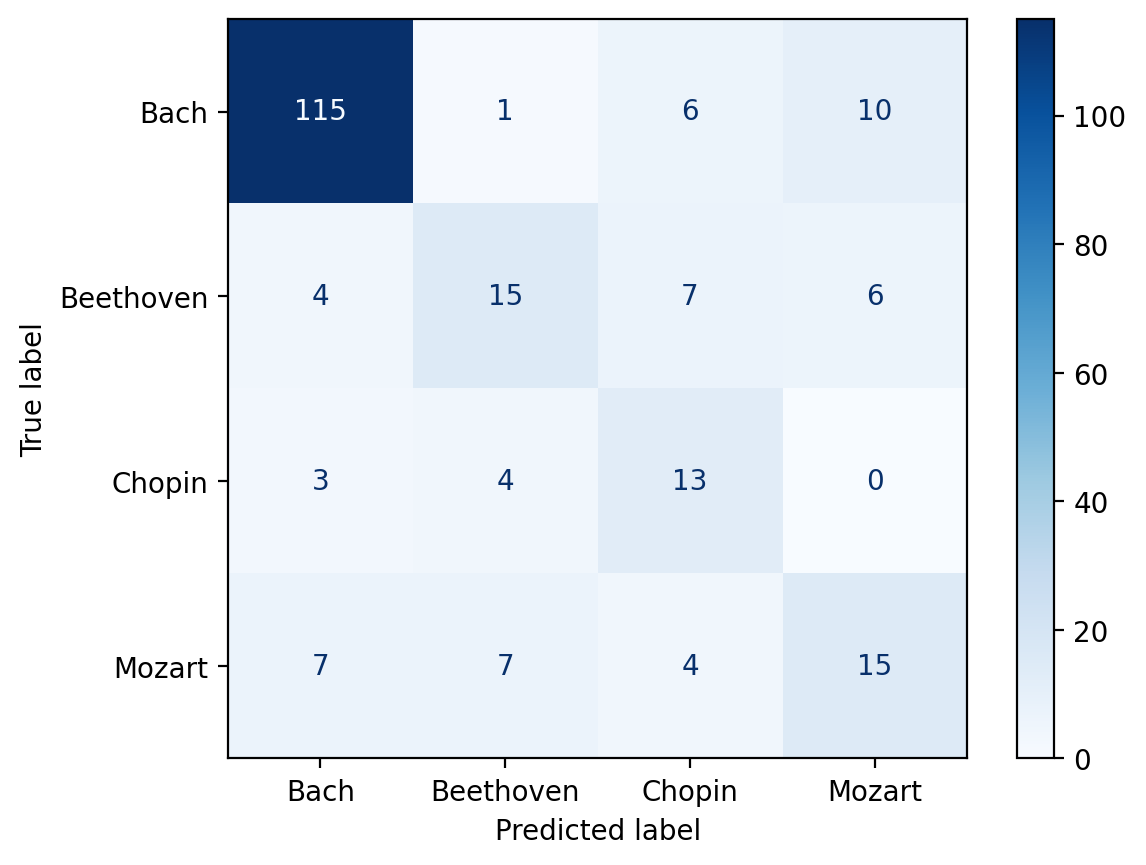

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, mask_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch, mask_batch)
        loss = criterion(logits, y_batch)

        predictions = logits.argmax(dim=1)

        test_loss += loss.item() * y_batch.size(0)
        test_correct += (predictions == y_batch).sum().item()
        test_total += y_batch.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

print("\nClassification report:")
print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=composer_names,
        digits=4,
    )
)

print("\nConfusion matrix:")
cm = confusion_matrix(all_targets, all_predictions)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=composer_names).plot(cmap=plt.cm.Blues)
plt.show()

# Model Optimization

Optimize the model using hyperparameter tuning.

In [47]:
from sklearn.metrics import f1_score

OPT_DIR = Path("optimization_outputs")
OPT_DIR.mkdir(parents=True, exist_ok=True)

print(">>> CNNLSTM OPTIMIZATION LOADED <<<")

NUM_FEATURES = int(X_train.shape[2])
NUM_CLASSES = len(label_to_index)


class CNNLSTMTunable(nn.Module):
    """Same architecture as `CNNLSTM`, with tunable capacity/dropout.

    Defaults match the non-optimized Model Building cell.
    """

    def __init__(
        self,
        num_features: int,
        num_classes: int,
        conv_channels: int = 32,
        cnn_out_channels: int = 128,
        lstm_hidden: int = 128,
        classifier_hidden: int = 64,
        dropout_cnn: float = 0.25,
        dropout_classifier: float = 0.30,
    ):
        super().__init__()

        self.conv1 = nn.Conv1d(num_features, conv_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(num_features, conv_channels, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(num_features, conv_channels, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(conv_channels * 3)
        self.conv4 = nn.Conv1d(conv_channels * 3, cnn_out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(cnn_out_channels)
        self.relu = nn.ReLU()
        self.dropout_cnn = nn.Dropout(dropout_cnn)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.lstm = nn.LSTM(
            input_size=cnn_out_channels,
            hidden_size=lstm_hidden,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, classifier_hidden),
            nn.ReLU(),
            nn.Dropout(dropout_classifier),
            nn.Linear(classifier_hidden, num_classes),
        )

    def forward(self, x, mask):
        x = x.transpose(1, 2)
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x))
        x3 = self.relu(self.conv3(x))
        x = torch.cat((x1, x2, x3), dim=1)
        x = self.dropout_cnn(self.relu(self.bn1(x)))
        x = self.pool(x)
        x = self.dropout_cnn(self.relu(self.bn2(self.conv4(x))))
        x = self.pool(x)

        mask = mask[:, ::2]
        mask = mask[:, ::2]
        x = x.transpose(1, 2)
        x = x * mask.unsqueeze(-1).float()
        lengths = mask.sum(dim=1).cpu().clamp(min=1)

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        hidden_combined = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.classifier(hidden_combined)


def make_loaders(batch_size: int):
    return (
        DataLoader(
            TensorDataset(X_train_t, mask_train_t, y_train_t),
            batch_size=batch_size,
            shuffle=True,
        ),
        DataLoader(
            TensorDataset(X_val_t, mask_val_t, y_val_t),
            batch_size=batch_size,
            shuffle=False,
        ),
        DataLoader(
            TensorDataset(X_test_t, mask_test_t, y_test_t),
            batch_size=batch_size,
            shuffle=False,
        ),
    )


def build_model(params: dict) -> nn.Module:
    return CNNLSTMTunable(
        num_features=NUM_FEATURES,
        num_classes=NUM_CLASSES,
        conv_channels=params["conv_channels"],
        cnn_out_channels=params["cnn_out_channels"],
        lstm_hidden=params["lstm_hidden"],
        classifier_hidden=params["classifier_hidden"],
        dropout_cnn=params["dropout_cnn"],
        dropout_classifier=params["dropout_classifier"],
    ).to(device)


@torch.no_grad()
def evaluate_loader(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    all_predictions = []
    all_targets = []
    all_probabilities = []

    for X_batch, mask_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch, mask_batch)
        loss = criterion(logits, y_batch)
        probabilities = torch.softmax(logits, dim=1)
        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * y_batch.size(0)
        total_correct += (predictions == y_batch).sum().item()
        total_examples += y_batch.size(0)
        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_targets.extend(y_batch.cpu().numpy().tolist())
        all_probabilities.append(probabilities.cpu().numpy())

    predictions_arr = np.asarray(all_predictions)
    targets_arr = np.asarray(all_targets)
    return {
        "loss": total_loss / max(total_examples, 1),
        "accuracy": total_correct / max(total_examples, 1),
        "macro_f1": float(
            f1_score(targets_arr, predictions_arr, average="macro", zero_division=0)
        ),
        "predictions": predictions_arr,
        "targets": targets_arr,
        "probabilities": np.concatenate(all_probabilities, axis=0)
        if all_probabilities
        else np.empty((0, NUM_CLASSES)),
    }


def train_cnnlstm(
    params: dict,
    *,
    max_epochs: int = 40,
    patience: int = 5,
    run_name: str = "cnnlstm_run",
):
    run_dir = OPT_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    train_loader_local, val_loader_local, test_loader_local = make_loaders(params["batch_size"])
    model_local = build_model(params)
    # Match the non-optimized training setup; optional light label smoothing only.
    label_smoothing = float(params.get("label_smoothing", 0.0))
    criterion_local = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer_local = torch.optim.Adam(
        model_local.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_local,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "learning_rate": [],
    }
    best_val_loss = float("inf")
    best_val_accuracy = 0.0
    best_val_macro_f1 = 0.0
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    grad_clip = float(params.get("grad_clip", 0.0))

    for epoch in range(1, max_epochs + 1):
        model_local.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, mask_batch, y_batch in train_loader_local:
            X_batch = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer_local.zero_grad()
            logits = model_local(X_batch, mask_batch)
            loss = criterion_local(logits, y_batch)
            loss.backward()
            if grad_clip > 0:
                nn.utils.clip_grad_norm_(model_local.parameters(), grad_clip)
            optimizer_local.step()

            train_loss += loss.item() * y_batch.size(0)
            train_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            train_total += y_batch.size(0)

        train_loss /= max(train_total, 1)
        train_accuracy = train_correct / max(train_total, 1)
        val_metrics = evaluate_loader(model_local, val_loader_local, criterion_local)
        scheduler.step(val_metrics["loss"])
        current_lr = optimizer_local.param_groups[0]["lr"]

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["learning_rate"].append(current_lr)

        print(
            f"[{run_name}] epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} acc={train_accuracy:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} "
            f"macro_f1={val_metrics['macro_f1']:.4f} | lr={current_lr:.2e}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_val_accuracy = val_metrics["accuracy"]
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model_local.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"[{run_name}] early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model_local.load_state_dict(best_state)

    metrics_path = run_dir / "training_metrics.csv"
    pd.DataFrame(history).to_csv(metrics_path, index=False)

    weights_path = run_dir / "model_weights.pt"
    torch.save(
        {
            "model_class": "CNNLSTMTunable",
            "base_architecture": "CNNLSTM",
            "params": params,
            "state_dict": model_local.state_dict(),
            "label_to_index": label_to_index,
            "composer_names": composer_names,
        },
        weights_path,
    )

    test_metrics = evaluate_loader(model_local, test_loader_local, criterion_local)
    predictions_df = pd.DataFrame(
        {
            "true_label_index": test_metrics["targets"],
            "pred_label_index": test_metrics["predictions"],
            "true_composer": [index_to_label[i] for i in test_metrics["targets"]],
            "pred_composer": [index_to_label[i] for i in test_metrics["predictions"]],
        }
    )
    for class_index, composer in index_to_label.items():
        predictions_df[f"prob_{composer}"] = test_metrics["probabilities"][:, class_index]

    predictions_path = run_dir / "test_predictions.csv"
    predictions_df.to_csv(predictions_path, index=False)

    summary = {
        "run_name": run_name,
        "params": params,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "best_val_macro_f1": best_val_macro_f1,
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "metrics_path": str(metrics_path),
        "weights_path": str(weights_path),
        "predictions_path": str(predictions_path),
    }
    with open(run_dir / "summary.json", "w", encoding="utf-8") as handle:
        json.dump(summary, handle, indent=2)

    return model_local, summary, pd.DataFrame(history)


print("Optimization helpers ready ->", OPT_DIR.resolve())


>>> CNNLSTM OPTIMIZATION LOADED <<<
Optimization helpers ready -> /content/optimization_outputs


In [45]:
import itertools

# Baseline-centered hyperparameter search.
# Always include the original non-optimized settings as trial 0.
BASELINE_PARAMS = {
    "learning_rate": 1e-4,
    "batch_size": 16,
    "weight_decay": 1e-4,
    "dropout_cnn": 0.25,
    "dropout_classifier": 0.30,
    "conv_channels": 32,
    "cnn_out_channels": 128,
    "lstm_hidden": 128,
    "classifier_hidden": 64,
    "label_smoothing": 0.0,
    "grad_clip": 0.0,
    "trial_id": 0,
}

PARAM_GRID = {
    "learning_rate": [1e-4, 2e-4, 5e-4],
    "batch_size": [16, 32, 64],
    "weight_decay": [1e-4, 1e-5],
    "dropout_cnn": [0.20, 0.30],
    "dropout_classifier": [0.25, 0.40],
    "conv_channels": [32],
    "cnn_out_channels": [96, 128],
    "lstm_hidden": [96, 128],
    "classifier_hidden": [64, 128],
    "label_smoothing": [0.0, 0.05],
    "grad_clip": [0.0, 1.0],
}

MAX_TRIALS = 9  # plus the explicit baseline trial => 10 total
TUNE_MAX_EPOCHS = 20
TUNE_PATIENCE = 5


def expand_param_grid(param_grid: dict, max_trials: int, seed: int = 42):
    keys = list(param_grid.keys())
    combinations = [
        dict(zip(keys, values))
        for values in itertools.product(*(param_grid[key] for key in keys))
    ]
    rng = np.random.default_rng(seed)
    if len(combinations) > max_trials:
        indices = rng.choice(len(combinations), size=max_trials, replace=False)
        combinations = [combinations[i] for i in sorted(indices.tolist())]
    for trial_id, params in enumerate(combinations, start=1):
        params = dict(params)
        params["trial_id"] = trial_id
        yield params


tune_results = []
search_params = [BASELINE_PARAMS] + list(expand_param_grid(PARAM_GRID, MAX_TRIALS))

for params in search_params:
    run_name = f"tune_cnnlstm_trial{params['trial_id']:02d}"
    print("\n" + "=" * 72)
    print(f"Tuning CNNLSTM | {run_name}")
    print(params)
    print("=" * 72)
    _, summary, _ = train_cnnlstm(
        params,
        max_epochs=TUNE_MAX_EPOCHS,
        patience=TUNE_PATIENCE,
        run_name=run_name,
    )
    tune_results.append(summary)

tune_df = pd.DataFrame(
    [
        {
            "run_name": row["run_name"],
            "best_val_loss": row["best_val_loss"],
            "best_val_accuracy": row["best_val_accuracy"],
            "best_val_macro_f1": row["best_val_macro_f1"],
            "test_accuracy": row["test_accuracy"],
            "test_macro_f1": row["test_macro_f1"],
            **{f"param_{k}": v for k, v in row["params"].items()},
        }
        for row in tune_results
    ]
).sort_values("best_val_loss")

tune_path = OPT_DIR / "hyperparameter_search_cnnlstm.csv"
tune_df.to_csv(tune_path, index=False)
display(tune_df)

best_params = min(tune_results, key=lambda row: row["best_val_loss"])["params"]
print("\nBest hyperparameters (by validation loss):")
print(best_params)
print("Saved search table ->", tune_path)



Tuning CNNLSTM (val-loss) | tune_cnnlstm_trial00
{'learning_rate': 0.0001, 'batch_size': 16, 'weight_decay': 0.0001, 'dropout_cnn': 0.25, 'dropout_classifier': 0.3, 'conv_channels': 32, 'cnn_out_channels': 128, 'lstm_hidden': 128, 'classifier_hidden': 64, 'label_smoothing': 0.0, 'grad_clip': 0.0, 'trial_id': 0}
[tune_cnnlstm_trial00] epoch 001 | train_loss=1.2507 acc=0.4755 | val_loss=0.8357 acc=0.7130 macro_f1=0.5472 | lr=1.00e-04
[tune_cnnlstm_trial00] epoch 002 | train_loss=1.0069 acc=0.5763 | val_loss=0.7585 acc=0.6991 macro_f1=0.5712 | lr=1.00e-04
[tune_cnnlstm_trial00] epoch 003 | train_loss=0.9351 acc=0.6162 | val_loss=0.7369 acc=0.6991 macro_f1=0.5721 | lr=1.00e-04
[tune_cnnlstm_trial00] epoch 004 | train_loss=0.8680 acc=0.6513 | val_loss=0.7141 acc=0.7037 macro_f1=0.5789 | lr=1.00e-04
[tune_cnnlstm_trial00] epoch 005 | train_loss=0.8135 acc=0.6843 | val_loss=0.6440 acc=0.7222 macro_f1=0.5974 | lr=1.00e-04
[tune_cnnlstm_trial00] epoch 006 | train_loss=0.7607 acc=0.7023 | val_l

,run_name,best_val_loss,best_val_accuracy,best_val_macro_f1,test_accuracy,test_macro_f1,param_learning_rate,param_batch_size,param_weight_decay,param_dropout_cnn,param_dropout_classifier,param_conv_channels,param_cnn_out_channels,param_lstm_hidden,param_classifier_hidden,param_label_smoothing,param_grad_clip,param_trial_id
5,tune_cnnlstm_trial05,0.459080,0.810185,0.726559,0.746544,0.639943,0.0002,16,0.00001,0.30,0.40,32,128,96,64,0.00,0.0,5
0,tune_cnnlstm_trial00,0.459958,0.847222,0.765473,0.774194,0.640822,0.0001,16,0.00010,0.25,0.30,32,128,128,64,0.00,0.0,0
8,tune_cnnlstm_trial08,0.464538,0.837963,0.748408,0.741935,0.603489,0.0005,16,0.00001,0.30,0.40,32,128,96,64,0.00,1.0,8
6,tune_cnnlstm_trial06,0.466360,0.819444,0.725991,0.728111,0.606208,0.0002,64,0.00001,0.30,0.40,32,96,96,64,0.00,0.0,6
2,tune_cnnlstm_trial02,0.467931,0.814815,0.744068,0.691244,0.579870,0.0001,16,0.00001,0.30,0.25,32,96,128,128,0.00,0.0,2
1,tune_cnnlstm_trial01,0.468732,0.796296,0.690280,0.686636,0.542311,0.0001,16,0.00001,0.30,0.25,32,96,96,128,0.00,1.0,1
3,tune_cnnlstm_trial03,0.497063,0.814815,0.684670,0.746544,0.605418,0.0001,32,0.00001,0.30,0.25,32,128,96,64,0.00,0.0,3
9,tune_cnnlstm_trial09,0.562400,0.837963,0.743897,0.714286,0.577239,0.0005,32,0.00001,0.20,0.40,32,128,96,128,0.05,1.0,9
4,tune_cnnlstm_trial04,0.583017,0.824074,0.724124,0.737327,0.608365,0.0002,16,0.00001,0.30,0.40,32,96,96,64,0.05,1.0,4
7,tune_cnnlstm_trial07,0.641576,0.763889,0.624157,0.737327,0.618455,0.0005,16,0.00010,0.30,0.25,32,96,96,128,0.05,0.0,7



Best hyperparameters (by validation loss):
{'learning_rate': 0.0002, 'batch_size': 16, 'weight_decay': 1e-05, 'dropout_cnn': 0.3, 'dropout_classifier': 0.4, 'conv_channels': 32, 'cnn_out_channels': 128, 'lstm_hidden': 96, 'classifier_hidden': 64, 'label_smoothing': 0.0, 'grad_clip': 0.0, 'trial_id': 5}
Saved search table -> optimization_outputs/hyperparameter_search_cnnlstm.csv


Training optimized CNNLSTM (validation-loss selection)...
[final_cnnlstm] epoch 001 | train_loss=1.1801 acc=0.4898 | val_loss=0.8060 acc=0.7037 macro_f1=0.5604 | lr=2.00e-04
[final_cnnlstm] epoch 002 | train_loss=0.9711 acc=0.5930 | val_loss=0.6847 acc=0.7407 macro_f1=0.6033 | lr=2.00e-04
[final_cnnlstm] epoch 003 | train_loss=0.8855 acc=0.6533 | val_loss=0.6895 acc=0.7269 macro_f1=0.6130 | lr=2.00e-04
[final_cnnlstm] epoch 004 | train_loss=0.8073 acc=0.6774 | val_loss=0.6695 acc=0.7222 macro_f1=0.6119 | lr=2.00e-04
[final_cnnlstm] epoch 005 | train_loss=0.7370 acc=0.7170 | val_loss=0.5988 acc=0.7546 macro_f1=0.6512 | lr=2.00e-04
[final_cnnlstm] epoch 006 | train_loss=0.6965 acc=0.7300 | val_loss=0.5450 acc=0.7685 macro_f1=0.6373 | lr=2.00e-04
[final_cnnlstm] epoch 007 | train_loss=0.6575 acc=0.7443 | val_loss=0.5176 acc=0.7639 macro_f1=0.6356 | lr=2.00e-04
[final_cnnlstm] epoch 008 | train_loss=0.5962 acc=0.7749 | val_loss=0.4981 acc=0.7778 macro_f1=0.6432 | lr=2.00e-04
[final_cnnlstm

,best_epoch,best_val_loss,best_val_accuracy,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,metrics_path,weights_path,predictions_path
0,8,0.498073,0.777778,0.643196,0.712631,0.700461,0.57301,optimization_outputs/final_cnnlstm/training_me...,optimization_outputs/final_cnnlstm/model_weigh...,optimization_outputs/final_cnnlstm/test_predic...


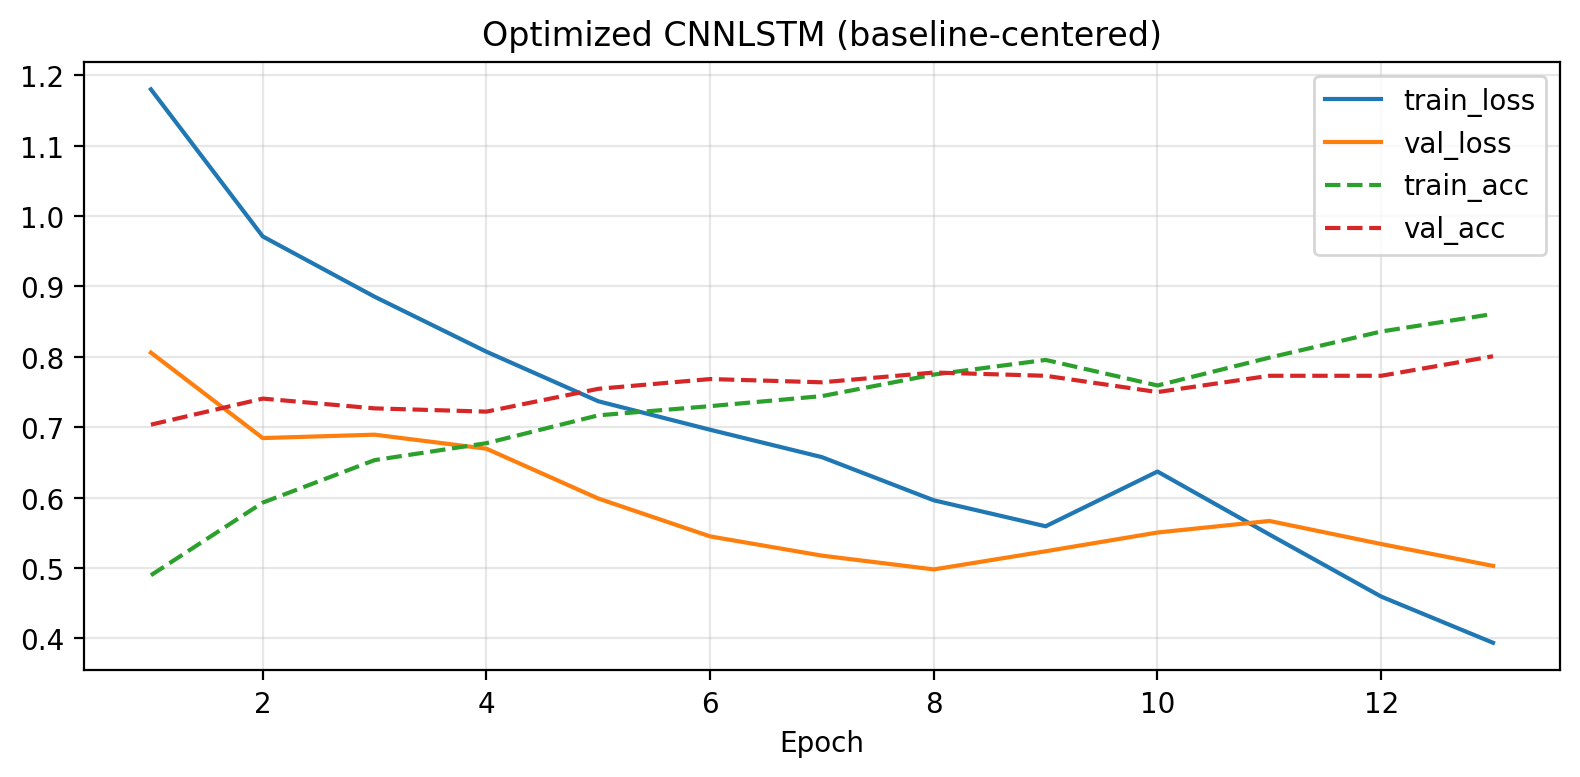


Classification report:
              precision    recall  f1-score   support

        Bach     0.9153    0.8182    0.8640       132
   Beethoven     0.4615    0.5625    0.5070        32
      Chopin     0.4737    0.4500    0.4615        20
      Mozart     0.4146    0.5152    0.4595        33

    accuracy                         0.7005       217
   macro avg     0.5663    0.5865    0.5730       217
weighted avg     0.7315    0.7005    0.7127       217


Saved under: /content/optimization_outputs/final_cnnlstm
  metrics     -> optimization_outputs/final_cnnlstm/training_metrics.csv
  weights     -> optimization_outputs/final_cnnlstm/model_weights.pt
  predictions -> optimization_outputs/final_cnnlstm/test_predictions.csv


In [46]:
# Retrain the best CNNLSTM and export artifacts.
FINAL_MAX_EPOCHS = 50
FINAL_PATIENCE = 5

print("Training optimized CNNLSTM")
optimized_model, optimized_summary, optimized_history = train_cnnlstm(
    best_params,
    max_epochs=FINAL_MAX_EPOCHS,
    patience=FINAL_PATIENCE,
    run_name="final_cnnlstm",
)

model = optimized_model
criterion = nn.CrossEntropyLoss(
    label_smoothing=float(best_params.get("label_smoothing", 0.0))
)

final_dir = OPT_DIR / "final_cnnlstm"
torch.save(optimized_model.state_dict(), final_dir / "best_cnn_lstm.pt")

with open(OPT_DIR / "best_hyperparameters.json", "w", encoding="utf-8") as handle:
    json.dump(optimized_summary, handle, indent=2)

print("\nOptimized CNNLSTM results:")
display(
    pd.DataFrame(
        [
            {
                k: optimized_summary[k]
                for k in [
                    "best_epoch",
                    "best_val_loss",
                    "best_val_accuracy",
                    "best_val_macro_f1",
                    "test_loss",
                    "test_accuracy",
                    "test_macro_f1",
                    "metrics_path",
                    "weights_path",
                    "predictions_path",
                ]
            }
        ]
    )
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(optimized_history["epoch"], optimized_history["train_loss"], label="train_loss")
ax.plot(optimized_history["epoch"], optimized_history["val_loss"], label="val_loss")
ax.plot(
    optimized_history["epoch"],
    optimized_history["train_accuracy"],
    label="train_acc",
    linestyle="--",
)
ax.plot(
    optimized_history["epoch"],
    optimized_history["val_accuracy"],
    label="val_acc",
    linestyle="--",
)
ax.set_title("Optimized CNNLSTM (baseline-centered)")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(final_dir / "training_curves.png", dpi=150)
plt.show()

pred_df = pd.read_csv(optimized_summary["predictions_path"])
print("\nClassification report:")
print(
    classification_report(
        pred_df["true_label_index"],
        pred_df["pred_label_index"],
        target_names=composer_names,
        digits=4,
    )
)

print(f"\nSaved under: {final_dir.resolve()}")
print(f"  metrics     -> {optimized_summary['metrics_path']}")
print(f"  weights     -> {optimized_summary['weights_path']}")
print(f"  predictions -> {optimized_summary['predictions_path']}")
